In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

In [75]:
df = pd.read_csv("best_data.csv")

In [76]:
df.Percent_Bleaching

0         50.90
1         51.00
2         51.30
3         51.38
4         51.40
          ...  
21923    100.00
21924    100.00
21925    100.00
21926    100.00
21927    100.00
Name: Percent_Bleaching, Length: 21928, dtype: float64

In [78]:
df = df[df.Percent_Bleaching > 1]

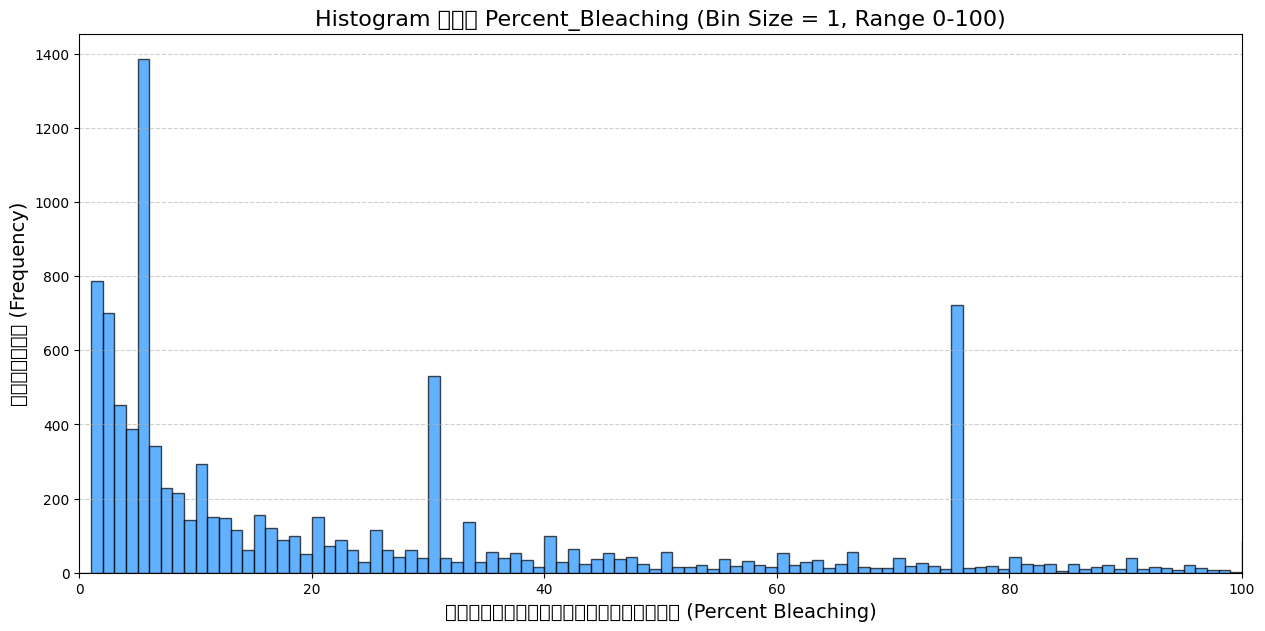

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# สมมติว่าข้อมูลของคุณอยู่ในตัวแปรชื่อ df['Percent_Bleaching']
# สร้าง Histogram
plt.figure(figsize=(15, 7))

# กำหนดช่วงของ bins ให้เริ่มจาก 0 ถึง 101 เพื่อให้แต่ละ bin มีความกว้างเท่ากับ 1 
# และครอบคลุมค่าตั้งแต่ 0 ถึง 100
bins = np.arange(0, 102) 

plt.hist(df['Percent_Bleaching'], bins=bins, color='dodgerblue', edgecolor='black', alpha=0.7)

# การตั้งค่ารายละเอียดของกราฟ
plt.title('Histogram ของ Percent_Bleaching (Bin Size = 1, Range 0-100)', fontsize=16)
plt.xlabel('เปอร์เซ็นต์การฟอกขาว (Percent Bleaching)', fontsize=14)
plt.ylabel('ความถี่ (Frequency)', fontsize=14)

# กำหนดขอบเขตของแกน X ให้ชัดเจนที่ 0 ถึง 100
plt.xlim(0, 100)

# เพิ่มเส้นตาราง (Grid) เฉพาะแกน Y เพื่อให้อ่านค่าความถี่ได้ง่ายขึ้น
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [10]:
df['Status'] = np.where(df['Percent_Bleaching'] <= 1, True, False)
X = df.drop(columns=["Percent_Bleaching", "Status"])   # ⭐ ลบทั้งคู่
Y_s = df.Status
Y_p = df.Percent_Bleaching

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, VotingClassifier,
    RandomForestRegressor, ExtraTreesRegressor, VotingRegressor, HistGradientBoostingRegressor
)
from sklearn.tree import DecisionTreeClassifier


# ============================================================
# 1. Perturbation Setup (สำหรับ Stage 2 Regressor)
# ============================================================
PERTURBATION_DICT = {
    'ClimSST':           0.5,
    'SSTA':              0.05,
    'Depth_m':           1.0,
    'Longitude_Degrees': 0.001,
    'Latitude_Degrees':  0.001,
}
PERTURB_FEATURES = ['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']


def perturb_feature_batch(X, feature, delta):
    """Perturb feature ทั้ง batch (vectorized) — สำหรับ classification + regression"""
    X_p, X_n = X.copy(), X.copy()
    X_p[feature] = X[feature] + delta
    X_n[feature] = X[feature] - delta
    
    # Clip ให้อยู่ในขอบเขตที่สมเหตุสมผล
    if feature == 'Depth_m':
        X_p[feature] = X_p[feature].clip(lower=0)
        X_n[feature] = X_n[feature].clip(lower=0)
    elif feature == 'Latitude_Degrees':
        X_p[feature] = X_p[feature].clip(-90, 90)
        X_n[feature] = X_n[feature].clip(-90, 90)
    elif feature == 'Longitude_Degrees':
        X_p[feature] = ((X_p[feature] + 180) % 360) - 180
        X_n[feature] = ((X_n[feature] + 180) % 360) - 180
    elif feature == 'ClimSST':
        X_p[feature] = X_p[feature].clip(lower=0)
        X_n[feature] = X_n[feature].clip(lower=0)
    
    return X_p, X_n


class PerturbationAwareEnsemble:
    """
    Per-sample adaptive weight ensemble — model ที่ robust ต่อ perturbation 
    ได้ weight สูงในการ fuse predictions
    """
    def __init__(self, models, perturbation_dict, features):
        self.models = models
        self.perturbation_dict = perturbation_dict
        self.features = features
    
    def fit(self, X, y):
        for m in self.models:
            m.fit(X, y)
        return self
    
    def predict(self, X):
        n_samples = len(X)
        n_models  = len(self.models)
        
        # baseline predictions
        base_preds = np.array([m.predict(X) for m in self.models])
        
        # คำนวณ error สะสมต่อ sample ต่อ model
        total_errors = np.zeros((n_models, n_samples))
        
        for feature in self.features:
            if feature in X.columns:
                delta = self.perturbation_dict[feature]
                X_p, X_n = perturb_feature_batch(X, feature, delta)
                
                for i, model in enumerate(self.models):
                    total_errors[i] += np.abs(model.predict(X_p) - base_preds[i])
                    total_errors[i] += np.abs(model.predict(X_n) - base_preds[i])
        
        # weight: inverse error (model ที่ robust → weight สูง)
        inverse = 1.0 / (total_errors + 1e-10)
        weights = inverse / inverse.sum(axis=0)
        
        # weighted prediction
        return (weights * base_preds).sum(axis=0)


# ============================================================
# 2. Hyperparameters (จาก Optuna Studies)
# ============================================================

# ----- Classification (Stage 1) -----
clf_rf_params = {
    'n_estimators': 500, 'max_depth': 45,
    'min_samples_split': 3, 'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'random_state': 42, 'n_jobs': -1,
}

clf_et_params = {
    'n_estimators': 423, 'max_depth': 23,
    'min_samples_split': 2, 'min_samples_leaf': 1,
    'max_features': None,
    'random_state': 42, 'n_jobs': -1,
}

# Bagging แยก base tree params จาก main params
bg_tree_depth = 20
bg_tree_leaf  = 1
clf_bg_params_cleaned = {
    'n_estimators': 90,
    'max_samples': 0.9869618111006297,
    'max_features': 0.6939338393935504,
    'bootstrap': False,
    'random_state': 42, 'n_jobs': -1,
}

# ----- Regression (Stage 2) -----
reg_et_params = {
    'n_estimators': 146, 'max_depth': 27,
    'min_samples_leaf': 1, 'max_features': 'sqrt',
    'random_state': 42, 'n_jobs': -1,
}

reg_rf_params = {
    'n_estimators': 197, 'max_depth': 26,
    'min_samples_split': 2, 'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'random_state': 42, 'n_jobs': -1,
}

reg_hgb_params = {
    'max_iter': 400, 'max_depth': 14,
    'learning_rate': 0.09675297292797276,
    'min_samples_leaf': 11,
    'l2_regularization': 0.010264285754308516,
    'random_state': 42,
}


# ============================================================
# 3. K-Fold (FIXED)
# ============================================================
df_full = pd.read_csv("best_data.csv")
df_full['Status'] = (df_full['Percent_Bleaching'] <= 1).astype(bool)

X_all = df_full.drop(columns=['Percent_Bleaching', 'Status'])
y_class = df_full['Status']
y_reg   = df_full['Percent_Bleaching']

# Reset index ตั้งแต่แรก
X_all   = X_all.reset_index(drop=True)
y_class = y_class.reset_index(drop=True)
y_reg   = y_reg.reset_index(drop=True)

month_cols = [f'Month_{i}' for i in range(1, 13)]
n_splits = 4
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

model_names = ['ExtraTrees', 'RandomForest', 'HistGradientBoost',
               'Standard Voting', 'Perturbation-Aware']
all_results = {name: [] for name in model_names}

print("="*85)
print(f"Two-Stage K-Fold Cross Validation (k={n_splits})")
print("="*85)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_all), 1):
    # Reset all indices หลัง split
    X_tr_raw = X_all.iloc[train_idx].reset_index(drop=True)
    X_te_raw = X_all.iloc[test_idx].reset_index(drop=True)
    y_cl_tr  = y_class.iloc[train_idx].reset_index(drop=True)
    y_cl_te  = y_class.iloc[test_idx].reset_index(drop=True)
    y_rg_tr  = y_reg.iloc[train_idx].reset_index(drop=True)
    y_rg_te  = y_reg.iloc[test_idx].reset_index(drop=True)

    # --- Preprocessing ใน fold ---
    X_num_tr = X_tr_raw.drop(columns=month_cols)
    
    imputer = SimpleImputer(strategy='median').fit(X_num_tr)
    X_tr_imp = imputer.transform(X_num_tr)
    
    scaler = StandardScaler().fit(X_tr_imp)
    X_tr_ss = scaler.transform(X_tr_imp)
    
    pca = PCA(n_components=0.75).fit(X_tr_ss)
    
    # Separate imputer for paper features (reattach)
    fe_imputer = SimpleImputer(strategy='median').fit(X_tr_raw[PERTURB_FEATURES])
    
    def transform_data(raw_df):
        num_part = raw_df.drop(columns=month_cols)
        pca_res  = pca.transform(scaler.transform(imputer.transform(num_part)))
        
        n_pcs = pca_res.shape[1]
        df_pca = pd.DataFrame(
            pca_res,
            columns=[f'PC{i+1}' for i in range(n_pcs)]
        ).reset_index(drop=True)
        
        # Impute paper features
        paper_imputed = pd.DataFrame(
            fe_imputer.transform(raw_df[PERTURB_FEATURES]),
            columns=PERTURB_FEATURES
        ).reset_index(drop=True)
        
        month_part = raw_df[month_cols].reset_index(drop=True)
        
        return pd.concat([df_pca, month_part, paper_imputed], axis=1)

    X_tr_final = transform_data(X_tr_raw)
    X_te_final = transform_data(X_te_raw)

    # --- STAGE 1: Classifier ---
    bg_tree = DecisionTreeClassifier(
        max_depth=bg_tree_depth,
        min_samples_leaf=bg_tree_leaf,
        random_state=42
    )
    clf = VotingClassifier(estimators=[
        ('rf', RandomForestClassifier(**clf_rf_params)),
        ('et', ExtraTreesClassifier(**clf_et_params)),
        ('bg', BaggingClassifier(estimator=bg_tree, **clf_bg_params_cleaned))
    ], voting='soft').fit(X_tr_final, y_cl_tr)
    
    pred_low_bleaching = clf.predict(X_te_final)

    # --- STAGE 2: Regressors ---
    # ใช้ ~y_cl_tr ชัดเจนกว่า y_rg_tr > 1 (logic เดียวกัน แต่ explicit)
    high_mask = ~y_cl_tr.values
    X_rg_tr_filtered = X_tr_final[high_mask].reset_index(drop=True)
    y_rg_tr_filtered = y_rg_tr[high_mask].reset_index(drop=True)
    
    reg_candidates = {
        'ExtraTrees':       ExtraTreesRegressor(**reg_et_params),
        'RandomForest':     RandomForestRegressor(**reg_rf_params),
        'HistGradientBoost': HistGradientBoostingRegressor(**reg_hgb_params),
        'Standard Voting':  VotingRegressor([
            ('et',  ExtraTreesRegressor(**reg_et_params)),
            ('rf',  RandomForestRegressor(**reg_rf_params)),
            ('hgb', HistGradientBoostingRegressor(**reg_hgb_params))
        ]),
        'Perturbation-Aware': PerturbationAwareEnsemble(
            models=[
                ExtraTreesRegressor(**reg_et_params),
                RandomForestRegressor(**reg_rf_params),
                HistGradientBoostingRegressor(**reg_hgb_params)
            ],
            perturbation_dict=PERTURBATION_DICT,
            features=PERTURB_FEATURES
        )
    }

    for name, model in reg_candidates.items():
        model.fit(X_rg_tr_filtered, y_rg_tr_filtered)
        
        final_preds = np.zeros(len(X_te_final))
        to_reg_mask = ~pred_low_bleaching
        
        if to_reg_mask.any():
            X_te_filtered = X_te_final[to_reg_mask].reset_index(drop=True)
            final_preds[to_reg_mask] = model.predict(X_te_filtered)
        
        all_results[name].append({
            'R2':   r2_score(y_rg_te, final_preds),
            'RMSE': np.sqrt(mean_squared_error(y_rg_te, final_preds)),
            'MAE':  mean_absolute_error(y_rg_te, final_preds)
        })
    
    print(f"Done Fold {fold}/{n_splits}")

# ============================================================
# 4. สรุปผล
# ============================================================
print("\n" + "="*85)
print(f"{'Final Two-Stage Model Comparison':<32} | {'Mean R2':>13} | "
      f"{'Mean RMSE':>14} | {'Mean MAE':>13}")
print("-" * 85)

for name in model_names:
    res_df = pd.DataFrame(all_results[name])
    m = res_df.mean()
    s = res_df.std()
    print(f"{name:<32} | {m['R2']:.4f}±{s['R2']:.3f} | "
          f"{m['RMSE']:7.4f}±{s['RMSE']:.3f} | "
          f"{m['MAE']:.4f}±{s['MAE']:.3f}")

print("="*85)

Two-Stage K-Fold Cross Validation (k=4)
Done Fold 1/4
Done Fold 2/4
Done Fold 3/4
Done Fold 4/4

Final Two-Stage Model Comparison |       Mean R2 |      Mean RMSE |      Mean MAE
-------------------------------------------------------------------------------------
ExtraTrees                       | 0.6699±0.012 | 12.3707±0.269 | 5.2972±0.168
RandomForest                     | 0.6597±0.015 | 12.5598±0.307 | 5.8483±0.184
HistGradientBoost                | 0.6549±0.014 | 12.6484±0.251 | 5.8436±0.118
Standard Voting                  | 0.6736±0.014 | 12.2998±0.275 | 5.5822±0.156
Perturbation-Aware               | 0.6716±0.014 | 12.3377±0.290 | 5.5870±0.164
